In [1]:
#@title Import
import os
# os.environ["JAX_PLATFORMS"] = 'cpu'

import math
import torch

import sys 
sys.path.append('..')

import jax
jax.config.update("jax_enable_x64", True)

from jax import numpy as jnp
from jax import random as jr
from jax import vmap, lax
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np

from dynamax.utils.plotting import plot_uncertainty_ellipses
from dynamax.linear_gaussian_ssm import LinearGaussianSSM, LinearGaussianConjugateSSM
from dynamax.linear_gaussian_ssm.inference import lgssm_filter, lgssm_smoother, lgssm_posterior_sample
from dynamax.linear_gaussian_ssm.inference import ParamsLGSSM, ParamsLGSSMInitial, ParamsLGSSMDynamics, ParamsLGSSMEmissions
from dynamax.linear_gaussian_ssm.inference import PosteriorGSSMFiltered, PosteriorGSSMSmoothed
from dynamax.parameters import ParameterProperties, ParameterSet
from dynamax.utils.utils import monotonically_increasing, random_rotation, pytree_slice, rotate_subspace, random_dynamics_weights, gram_schmidt
from dynamax.utils.distributions import NormalInverseWishart as NIW
from dynamax.nonlinear_gaussian_ssm import StiefelManifoldSSM
from dynamax.linear_gaussian_ssm.inference import ParamsLGSSMInitial, ParamsLGSSMDynamics
from dynamax.nonlinear_gaussian_ssm.models import ParamsSMDS, ParamsSMDSEmissions
from tensorflow_probability.substrates.jax.distributions import MultivariateNormalFullCovariance as MVN
from tensorflow_probability.substrates.jax.distributions import InverseGamma as IG
from dynamax.linear_gaussian_ssm.inference import make_lgssm_params


from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score, explained_variance_score
from sklearn.cluster import KMeans

from scipy.spatial import distance_matrix, distance
from scipy.stats import chi2
import scipy.signal as signal
from scipy.special import logsumexp
from scipy.ndimage import gaussian_filter, gaussian_filter1d

from sklearn.decomposition import PCA

from tensorflow_probability.substrates import jax as tfp

import torch
import torch.nn.functional as F

from tqdm import tqdm

import h5py
import pandas as pd
import csv
import pickle as pkl

from collections import defaultdict

import time

import wandb
import re

In [2]:
def random_orthogonal(key, n):
    # QR of a Gaussian matrix → orthogonal. Fix det=+1.
    M = jr.normal(key, (n, n))
    Q, R = jnp.linalg.qr(M)
    # make Q a rotation (det=+1)
    sign = jnp.sign(jnp.linalg.det(Q))
    Q = Q.at[:, -1].set(Q[:, -1] * sign)
    return Q

def scaled_rotation_block(r, theta):
    c, s = jnp.cos(theta), jnp.sin(theta)
    R = jnp.array([[c, -s],
                   [s,  c]])
    return r * R

def dynamics_with_distinct_magnitudes(key, dim,
                                      r_low=0.85, r_high=1.05,
                                      theta_low=jnp.pi/16, theta_high=jnp.pi/2):
    """
    Returns A = Q @ B @ Q.T where B is block-diagonal with 2x2 blocks r_i*R(theta_i)
    (and an optional 1x1 real block). Eigenvalue magnitudes are {r_i} (all different).
    """
    key_Q, key_r, key_th, key_eps = jr.split(key, 4)

    # number of 2x2 blocks
    m = dim // 2
    has_scalar = (dim % 2 == 1)

    # sample radii and nudge them to ensure distinctness
    r = jr.uniform(key_r, (m,), minval=r_low, maxval=r_high)
    # add tiny sorted jitter so ties are virtually impossible but stable
    eps = jr.uniform(key_eps, (m,), minval=1e-4, maxval=5e-4)
    r = jnp.sort(r) + jnp.sort(eps)

    # sample angles
    thetas = jr.uniform(key_th, (m,), minval=theta_low, maxval=theta_high)

    # build block-diagonal B
    B = jnp.zeros((dim, dim))
    idx = 0
    for i in range(m):
        blk = scaled_rotation_block(r[i], thetas[i])
        B = B.at[idx:idx+2, idx:idx+2].set(blk)
        idx += 2

    if has_scalar:
        # single real eigenvalue with a different magnitude than any r_i
        # pick it outside the r range to guarantee distinctness
        r_scalar = (r_high + 0.02)
        B = B.at[-1, -1].set(r_scalar)

    # scramble with a random orthogonal similarity → preserves eigenvalues
    Q = random_orthogonal(key_Q, dim)
    A = Q @ B @ Q.T
    return A

# def polar_SO(M: torch.Tensor):
#     """
#     Closest rotation (SO(D)) to M via SVD; avoids reflections.
#     Args:
#         M: (..., D, D) real tensor
#     Returns:
#         R: (..., D, D) rotation (det=+1)
#         s: (..., D) singular values of M
#     """
#     U, s, Vh = torch.linalg.svd(M, full_matrices=False)          # M ≈ U @ diag(s) @ Vh
#     det = torch.det(U @ Vh)                                      # (...,)

#     D = U.shape[-1]
#     J = torch.eye(D, dtype=M.dtype, device=M.device)             # (D, D)
#     J = J.expand(U.shape[:-2] + (D, D)).clone()                  # (..., D, D)
#     J[..., -1, -1] = torch.where(det < 0, M.new_tensor(-1.0), M.new_tensor(1.0))

#     R = U @ J @ Vh
#     return R, s


# def within_twist(R: torch.Tensor):
#     """
#     Exact within-plane twist from eigen-phases of R ∈ O(D).
#     Returns sqrt(sum(theta_i^2)) where eigenvalues are e^{± i theta_i}.
#     Works on CPU or GPU (torch.linalg.eigvals is CUDA-capable).
#     """
#     evals = torch.linalg.eigvals(R)                              # (..., D) complex
#     # print(evals.shape)
#     angles = torch.abs(torch.angle(evals))                       # (..., D) in [0, π]
#     return torch.linalg.norm(angles, dim=-1) / math.sqrt(2.0)    # (...,)

# def twist_angles(A: torch.Tensor, B: torch.Tensor):
#     """
#     Scalar geodesic 'twist' between A and B (rotation-only, ignores scale/shear).
#     A: (..., N, D) with orthonormal columns (A^T A = I)
#     B: (..., N, D) with orthonormal columns (B^T B = I)
#     """
#     M = A.transpose(-1, -2) @ B          # (..., D, D)
#     R, _ = polar_SO(M)
#     return within_twist(R)               # (...,)


# # ---------- Pairwise T×T twist for weights ∈ R^{T×N×D} ----------

# def compute_twist_angle_matrix(weights: torch.Tensor):
#     """
#     weights: (T, N, D), each slice weights[t] has orthonormal columns (Stiefel: N×D).
#     Returns:
#         twists: (T, T) where twists[i, j] is the rotation-only geodesic twist
#                 between weights[i] and weights[j].
#     """
#     assert weights.ndim == 3, "weights must be (T, N, D)"
#     T, N, D = weights.shape

#     # Build all pairwise M_ij = A_i^T @ B_j  →  shape (T, T, D, D)
#     A_T = weights.transpose(-1, -2)                  # (T, D, N)
#     M = A_T[:, None, ...] @ weights[None, :, ...]    # (T, 1, D, N) @ (1, T, N, D) -> (T, T, D, D)

#     # Project to closest rotations and compute twists
#     R, _ = polar_SO(M)                                # (T, T, D, D)
#     twists = within_twist(R)                          # (T, T)
#     return twists





def polar_SO(M: torch.Tensor):
    """
    Closest rotation (SO(D)) to M via SVD; avoids reflections.
    Args:
        M: (..., D, D) real tensor
    Returns:
        R: (..., D, D) rotation (det=+1)
        s: (..., D) singular values of M
    """
    U, s, Vh = torch.linalg.svd(M, full_matrices=False)          # M ≈ U @ diag(s) @ Vh
    det = torch.det(U @ Vh)                                      # (...,)

    D = U.shape[-1]
    J = torch.eye(D, dtype=M.dtype, device=M.device)             # (D, D)
    J = J.expand(U.shape[:-2] + (D, D)).clone()                  # (..., D, D)
    J[..., -1, -1] = torch.where(det < 0, M.new_tensor(-1.0), M.new_tensor(1.0))

    R = U @ J @ Vh
    return R, s


# def within_twist(R: torch.Tensor):
#     """
#     Exact within-plane twist from eigen-phases of R ∈ O(D).
#     Returns sqrt(sum(theta_i^2)) where eigenvalues are e^{± i theta_i}.
#     Works on CPU or GPU (torch.linalg.eigvals is CUDA-capable).
#     """
#     evals = torch.linalg.eigvals(R)                              # (..., D) complex
#     # print(evals.shape)
#     angles = torch.abs(torch.angle(evals))                       # (..., D) in [0, π]
#     # return torch.linalg.norm(angles, dim=-1) / math.sqrt(2.0)    # (...,)
#     return torch.linalg.norm(angles[:, :, ::2], dim=-1)    # (...,)

def within_twist(R: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
    """
    Geodesic distance on SO(D) from eigen-phases.
    Returns sqrt(sum(theta_i^2)) where eigenvalues are e^{± i theta_i}.
    """
    evals = torch.linalg.eigvals(R)                  # (..., D) complex
    angles = torch.abs(torch.angle(evals))           # (..., D) in [0, π]
    # kill tiny numerical noise near 0
    angles = torch.where(angles < eps, angles.new_zeros(()), angles)
    return torch.linalg.norm(angles, dim=-1) / math.sqrt(2.0)

def twist_angles(A: torch.Tensor, B: torch.Tensor):
    """
    Scalar geodesic 'twist' between A and B (rotation-only, ignores scale/shear).
    A: (..., N, D) with orthonormal columns (A^T A = I)
    B: (..., N, D) with orthonormal columns (B^T B = I)
    """
    M = A.transpose(-1, -2) @ B          # (..., D, D)
    R, _ = polar_SO(M)
    return within_twist(R)               # (...,)


# ---------- Pairwise T×T twist for weights ∈ R^{T×N×D} ----------

def compute_twist_angle_matrix(weights: torch.Tensor):
    """
    weights: (T, N, D), each slice weights[t] has orthonormal columns (Stiefel: N×D).
    Returns:
        twists: (T, T) where twists[i, j] is the rotation-only geodesic twist
                between weights[i] and weights[j].
    """
    assert weights.ndim == 3, "weights must be (T, N, D)"
    T, N, D = weights.shape

    # Build all pairwise M_ij = A_i^T @ B_j  →  shape (T, T, D, D)
    A_T = weights.transpose(-1, -2)                  # (T, D, N)
    M = A_T[:, None, ...] @ weights[None, :, ...]    # (T, 1, D, N) @ (1, T, N, D) -> (T, T, D, D)

    # Project to closest rotations and compute twists
    R, _ = polar_SO(M)                                # (T, T, D, D)
    twists = within_twist(R)                          # (T, T)
    return twists












def subspace_angles(A, B):
    """
    Compute the angle between two subspaces
    https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.subspace_angles.html
    """

    # 1. Compute orthonormal bases of column spaces
    QA = jnp.linalg.svd(A, full_matrices=False)[0]
    QB = jnp.linalg.svd(B, full_matrices=False)[0]

    # 2. Compute SVD for cosine
    QA_H_QB = jnp.dot(QA.T.conj(), QB)
    sigma = jnp.linalg.svd(QA_H_QB, full_matrices=False, compute_uv=False)

    # 3. Compute matrix B
    B = QB - jnp.dot(QA, QA_H_QB)

    # 4. Compute SVD for sine
    mask = sigma ** 2 >= 0.5
    mu_arcsin = jnp.arcsin(jnp.clip(jnp.linalg.svd(B, full_matrices=False, compute_uv=False), a_min=-1., a_max=1.))

    # 5. Compute the principal angles
    theta = jnp.where(mask, mu_arcsin, jnp.arccos(jnp.clip(sigma[::-1], a_min=-1., a_max=1.)))

    return theta

def compute_subspace_angle_matrix_v2(weights):
    # weights: T x N x D
    # output: T x T

    T = weights.shape[0]

    def _compute_subspace_angles(carry, anchor):
        sa = vmap(subspace_angles, in_axes=(0, None))(weights, weights[anchor])
        return None, sa

    _, subspace_angle_matrix = lax.scan(_compute_subspace_angles, init=None, xs=jnp.arange(T))

    return subspace_angle_matrix

def compute_rotation(observations, emissions):
    """
    Given:
      observations: jnp.ndarray of shape (num_trials, num_timesteps, emission_dim)
      emissions:    jnp.ndarray of shape (num_trials, emission_dim, latent_dim)
    Returns:
      R: jnp.ndarray of shape (latent_dim, latent_dim)
         A rotation matrix such that rotating each trial's emission matrix (i.e. computing O_i @ R)
         orders the latent columns in descending order of explained variance.
      explained_variances: jnp.ndarray of shape (latent_dim,)
         Variances explained by the rotated latent dimensions.
    """
    # Compute latent factors per trial: shape (num_trials, num_timesteps, latent_dim)
    # Using the fact that the emission matrices are orthogonal.
    latent_factors = jnp.einsum('...te,...el->...tl', observations, emissions)
    
    # Stack trials and timesteps together, so we have all latent factors in one 2D array.
    if latent_factors.ndim == 3:
        num_trials, num_timesteps, latent_dim = latent_factors.shape
    else:
        num_timesteps, latent_dim = latent_factors.shape
        num_trials = 1

    latent_factors_stacked = latent_factors.reshape(num_trials * num_timesteps, latent_dim)
    
    # Perform SVD on the aggregated latent factors.
    # latent_factors_stacked = U @ diag(S) @ Vt, with singular values S in descending order.
    U, S, Vt = jnp.linalg.svd(latent_factors_stacked, full_matrices=False)
    
    # The rotation matrix that aligns with the principal directions is given by V = Vt.T.
    # Rotating the latent factors as L_rot = latent_factors_stacked @ V will yield columns
    # with decreasing variance (S^2 are proportional to the variances).
    R = Vt.T
    
    # Compute the explained variances for each rotated latent dimension.
    explained_variances = (S ** 2) / (latent_factors_stacked.shape[0] - 1)
    
    return R, explained_variances

def explained_variance(observations, emissions):
    """
    Given:
      observations: jnp.ndarray of shape (num_trials, num_timesteps, emission_dim)
      emissions:    jnp.ndarray of shape (num_trials, emission_dim, latent_dim)
    Returns:
      R: jnp.ndarray of shape (latent_dim, latent_dim)
         A rotation matrix such that rotating each trial's emission matrix (i.e. computing O_i @ R)
         orders the latent columns in descending order of explained variance.
      explained_variances: jnp.ndarray of shape (latent_dim,)
         Variances explained by the rotated latent dimensions.
    """
    # Compute latent factors per trial: shape (num_trials, num_timesteps, latent_dim)
    # Using the fact that the emission matrices are orthogonal.
    latent_factors = jnp.einsum('...te,...el->...tl', observations, emissions)
    
    # Stack trials and timesteps together, so we have all latent factors in one 2D array.
    if latent_factors.ndim == 3:
        num_trials, num_timesteps, latent_dim = latent_factors.shape
    else:
        num_timesteps, latent_dim = latent_factors.shape
        num_trials = 1
    latent_factors_stacked = latent_factors.reshape(num_trials * num_timesteps, latent_dim)
    
    # Perform SVD on the aggregated latent factors.
    # latent_factors_stacked = U @ diag(S) @ Vt, with singular values S in descending order.
    U, S, Vt = jnp.linalg.svd(latent_factors_stacked, full_matrices=False)
    
    # Compute the explained variances for each rotated latent dimension.
    explained_variances = (S ** 2) / (latent_factors_stacked.shape[0] - 1)
    
    return explained_variances

def compute_explained_variance(y, full_H, H):
    ev = explained_variance(y, H)
    total_ev = explained_variance(y, full_H).sum()
    return ev / total_ev

def compute_cos_dist(a, b):
    def _l2(x):
        return jnp.sqrt(jnp.sum(jnp.square(x)))
    return 1 - (a @ b) / (_l2(a) * _l2(b))

def compute_cos_sim(a, b):
    def _l2(x):
        return jnp.sqrt(jnp.sum(jnp.square(x)))
    return (a @ b) / (_l2(a) * _l2(b))

def plot_eigenvalues(
    true_A: np.ndarray,
    smds_A: np.ndarray,
    lds_A: np.ndarray,
    figsize: tuple = (4, 4),
    title: str = "Eigenvalues of Dynamics Matrix",
):
    """
    Plot eigenvalues of two dynamics matrices in the complex plane.

    Parameters
    ----------
    A_stationary : np.ndarray
        Dynamics matrix expected to be (asymptotically) stable
        (eigenvalues inside or on the unit circle).
    A_nonstationary : np.ndarray
        Dynamics matrix that may be unstable or marginally stable.
    figsize : tuple, optional
        Size of the matplotlib figure.
    title : str, optional
        Title of the plot.
    """
    # --- compute eigenvalues -------------------------------------------------
    eig_true = np.linalg.eigvals(true_A)
    eig_smds = np.linalg.eigvals(smds_A)
    eig_lds = np.linalg.eigvals(lds_A)

    # --- set up figure -------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Real Part")
    ax.set_ylabel("Imaginary Part")
    ax.grid(True, linestyle="--", alpha=0.5)

    # Equal aspect so the unit circle looks like a circle
    ax.set_aspect("equal", adjustable="box")

    # --- unit circle ---------------------------------------------------------
    theta = np.linspace(0, 2 * np.pi, 400)
    ax.plot(np.cos(theta), np.sin(theta), "k--", lw=1.5)

    # --- scatter eigenvalues -------------------------------------------------
    ax.scatter(
        eig_true.real,
        eig_true.imag,
        c="k",
        marker="o",
        s=70,
        label="Eigenvalues (True SMDS)",
    )
    ax.scatter(
        eig_smds.real,
        eig_smds.imag,
        c="red",
        marker="o",
        label="Eigenvalues (Learned SMDS)",
    )

    ax.scatter(
        eig_lds.real,
        eig_lds.imag,
        c="blue",
        marker="o",
        label="Eigenvalues (Learned LDS)",
    )

    ax.legend(loc="upper left", fontsize=8)
    plt.show()

def moving_average_adaptive(x, window_size):
    kernel = jnp.ones(window_size)

    # Numerator: regular convolution
    smoothed = jnp.convolve(x, kernel, mode='same')

    # Denominator: convolution with ones to count valid entries
    counts = jnp.convolve(jnp.ones_like(x), kernel, mode='same')

    return smoothed / counts

In [117]:
true_state_dim = 8
emission_dim = 24
num_trials = 750
num_conditions = 4
num_timesteps = 30

os.makedirs("figure2_variance_drift", exist_ok=True)

dof = true_state_dim * (emission_dim - true_state_dim) + true_state_dim * (true_state_dim - 1) // 2

true_model = StiefelManifoldSSM(state_dim=true_state_dim, 
                                emission_dim=emission_dim,
                                num_trials=num_trials,
                                num_conditions=num_conditions)

key = jr.PRNGKey(1234)
# key = jr.PRNGKey(42)
# n_rotations = 16
# dynamics = random_rotation(seed=k1, n=true_state_dim, theta=jnp.pi/5)
# for n in range(n_rotations):
#     key, k1, k2, k3 = jr.split(key, 4)
#     dynamics = dynamics @ (jr.uniform(key=k2, minval=0.9, maxval=1.05) * random_rotation(seed=k1, n=true_state_dim, theta=jnp.pi/jr.uniform(key=k3, minval=3, maxval=7)))
dynamics = dynamics_with_distinct_magnitudes(key, true_state_dim)


key, key_root = jr.split(key)
true_base_subspace = jr.orthogonal(key_root, emission_dim)

variance_axis_profile = jnp.linspace(1.75, 1.0, true_state_dim)
drift_tau_by_axis = jnp.exp(jnp.linspace(jnp.log(1e-4), jnp.log(1e-6), true_state_dim))
true_scale = jnp.tile(variance_axis_profile[None], (num_trials, 1))

in_manifold_dof = true_state_dim * (true_state_dim - 1) // 2
out_manifold_tau = jnp.repeat(drift_tau_by_axis[:, None], emission_dim - true_state_dim, axis=1).reshape(-1)
true_tau = jnp.concatenate([jnp.ones(in_manifold_dof) * 1e-10, out_manifold_tau])

_velocity_cov = jnp.diag(true_tau)
def _get_velocity(prev_velocity, current_key):
    current_velocity_dist = MVN(loc=prev_velocity, covariance_matrix=_velocity_cov)
    current_velocity = current_velocity_dist.sample(seed=current_key)
    return current_velocity, current_velocity

keys = jr.split(key, num_trials)
key = keys[-1]
key, key_root = jr.split(key)
_initial_velocity = jnp.zeros(dof)
_, _velocity = jax.lax.scan(_get_velocity, _initial_velocity, keys[:-1])
_velocity = jnp.concatenate([_initial_velocity[None], _velocity])
true_tau = jnp.var(jnp.diff(_velocity, axis=0), axis=0)

key, key_root = jr.split(key)
true_params, param_props, true_velocity = true_model.initialize(tau=true_tau,
                                                                base_subspace=true_base_subspace,
                                                                key=key, 
                                                                initial_mean=jnp.sqrt(emission_dim/true_state_dim)*jr.normal(key_root, shape=(num_conditions, true_state_dim)),
                                                                dynamics_weights=dynamics,
                                                                # dynamics_bias=jr.normal(key_root, true_state_dim),
                                                                dynamics_covariance=jnp.eye(true_state_dim)*1e-1,
                                                                emission_covariance=jnp.eye(emission_dim)*1e-1,
                                                                velocity=_velocity,
                                                                scale=true_scale,
                                                                )

conditions = jnp.tile(jnp.arange(num_conditions), num_trials)[:num_trials]
key, key_root = jr.split(key)
true_states, emissions, _ = true_model.sample(true_params, key, num_timesteps, conditions=conditions)


In [118]:
D = state_dim=true_params.initial.mean.shape[-1]
N = emission_dim=true_params.emissions.weights.shape[-2]
num_trials=len(true_params.emissions.weights)
num_conditions = true_params.initial.mean.shape[0]

num_timesteps=emissions.shape[-2]

dof = state_dim * (emission_dim - state_dim)
dof_shape = (state_dim, emission_dim - state_dim)

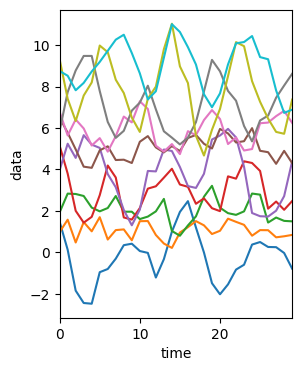

In [119]:
# Plot the true states and emissions
fig, ax = plt.subplots(figsize=(3, 4))
ax.plot(emissions[-1, :, :min(10, N)] + 1 * jnp.arange(min(10, N)))
ax.set_ylabel("data")
ax.set_xlabel("time")
ax.set_xlim(0, num_timesteps - 1)
plt.show()

In [120]:
true_emissions_weights = true_params.emissions.weights
print(true_emissions_weights.shape)

(750, 24, 8)


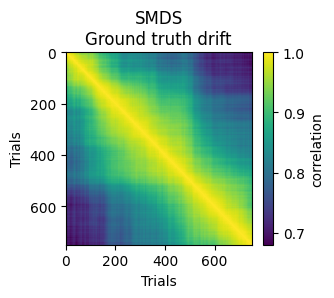

In [121]:
true_corrcoef = jnp.corrcoef(true_emissions_weights.reshape(len(emissions), -1))
plt.figure(figsize=(3,2.5))
plt.imshow(true_corrcoef, aspect='auto', interpolation='none')
# plt.colorbar(label='Emission matrix correlation')
plt.ylabel('Trials')
plt.xlabel('Trials')
# plt.yticks(np.array([0, 750, 1500])-0.5, [1, 750, 1500])
# plt.xticks(np.array([0, 750, 1500])-0.5, [1, 750, 1500])
plt.title('SMDS\nGround truth drift')
plt.colorbar(label='correlation')
# plt.savefig('simulated_true_C_corrcoef_drift.pdf', bbox_inches='tight', facecolor='white')
plt.show()

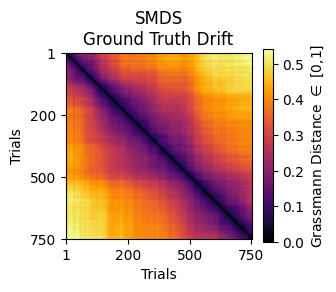

In [122]:
subspace_angle_matrix = compute_subspace_angle_matrix_v2(true_emissions_weights[:, :, :])
normalized_grassmann_dist_matrix = jnp.linalg.norm(subspace_angle_matrix, ord=2, axis=-1) / (jnp.sqrt(state_dim) * jnp.pi / 2)

plt.figure(figsize=(3,2.5))
# plt.imshow(normalized_grassmann_dist_matrix, interpolation='None', vmin=0.0, vmax=0.3615, cmap='inferno')
plt.imshow(normalized_grassmann_dist_matrix, interpolation='None', vmin=0.0, cmap='inferno')
# plt.colorbar(label='Grassmann Distance\nNormalized to [0,1]')
plt.colorbar(label=r'Grassmann Distance $\in$ [0,1]')
plt.title(f'SMDS\nGround Truth Drift')
plt.xticks([0, 250, 500, 749], [1, 200, 500, 750])
plt.yticks([0, 250, 500, 749], [1, 200, 500, 750])
# plt.xticks([0, 20//block_size, 40//block_size, 60//block_size, 80//block_size, 100//block_size, 120//block_size],
#            [1, 20, 40, 60, 80, 100, 120])
# plt.yticks([0, 20//block_size, 40//block_size, 60//block_size, 80//block_size, 100//block_size, 120//block_size],
#            [1, 20, 40, 60, 80, 100, 120])
plt.ylabel('Trials')
plt.xlabel('Trials')
# plt.savefig('./figure2_variance_drift/figure2_smds_true_drift_final_v2.png', bbox_inches='tight', facecolor='white', dpi=600)
plt.show()

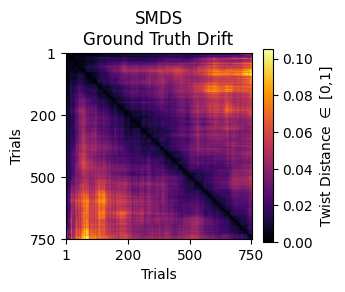

In [123]:
# twist_angle_matrix = compute_twist_angle_matrix(true_emissions_weights[:, :, :])
twist_angle_matrix = compute_twist_angle_matrix(torch.tensor(np.array(true_emissions_weights, copy=True), device='cuda'))
twist_angle_matrix = jnp.array(twist_angle_matrix.cpu().numpy())
d_in_max = jnp.pi * jnp.sqrt(D // 2)
normalized_twist_angle_matrix = jnp.clip(twist_angle_matrix / d_in_max, 0.0, 1.0)

plt.figure(figsize=(3,2.5))
# plt.imshow(normalized_grassmann_dist_matrix, interpolation='None', vmin=0.0, vmax=0.3615, cmap='inferno')
plt.imshow(normalized_twist_angle_matrix, interpolation='None', vmin=0.0, cmap='inferno')
# plt.colorbar(label='Grassmann Distance\nNormalized to [0,1]')
plt.colorbar(label=r'Twist Distance $\in$ [0,1]')
plt.title(f'SMDS\nGround Truth Drift')
plt.xticks([0, 250, 500, 749], [1, 200, 500, 750])
plt.yticks([0, 250, 500, 749], [1, 200, 500, 750])
# plt.xticks([0, 20//block_size, 40//block_size, 60//block_size, 80//block_size, 100//block_size, 120//block_size],
#            [1, 20, 40, 60, 80, 100, 120])
# plt.yticks([0, 20//block_size, 40//block_size, 60//block_size, 80//block_size, 100//block_size, 120//block_size],
#            [1, 20, 40, 60, 80, 100, 120])
plt.ylabel('Trials')
plt.xlabel('Trials')
# plt.savefig('./figure2_variance_drift/figure2_smds_true_drift_final_v2.png', bbox_inches='tight', facecolor='white', dpi=600)
plt.show()

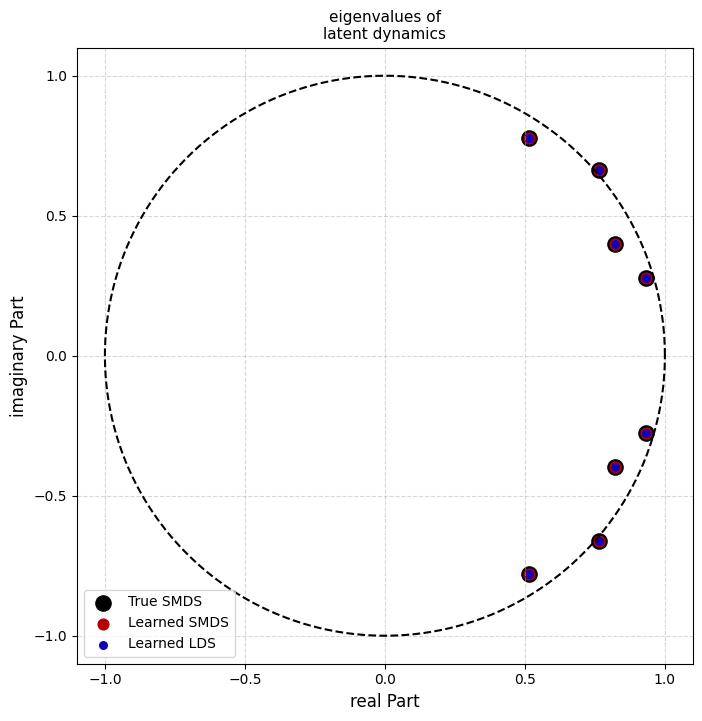

In [124]:
true_rotation, _ = compute_rotation(emissions, true_params.emissions.weights)
A = true_params.dynamics.weights
true_rotation_inv = jnp.linalg.inv(true_rotation)
transformed_true_A = true_rotation @ A @ true_rotation_inv

plot_eigenvalues(transformed_true_A, transformed_true_A, transformed_true_A, figsize=(8,8))

In [125]:
true_emissions_weights = true_params.emissions.weights

In [126]:
R, explained_variances = compute_rotation(emissions, true_emissions_weights)
rotated_true_emissions_weights = jnp.einsum('rij,jk->rik', true_emissions_weights, R)
true_evs = vmap(compute_explained_variance, in_axes=(None, None, -1))(emissions, rotated_true_emissions_weights, rotated_true_emissions_weights[:, :, None])
original_true_evs = vmap(compute_explained_variance, in_axes=(None, None, -1))(emissions, true_emissions_weights, 
                                                                               true_emissions_weights[:, :, None])

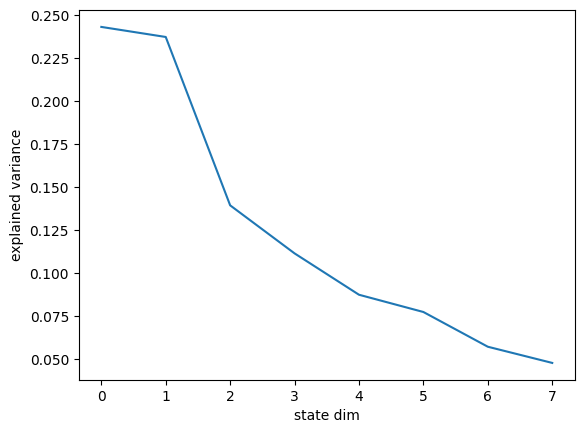

In [127]:
fig, ax = plt.subplots()
ax.plot(np.arange(D), true_evs)
ax.set_ylabel('explained variance')
ax.set_xlabel('state dim')
plt.show()

In [128]:
true_cos_sims = np.zeros((D, num_trials))
true_cos_dists = np.zeros((D, num_trials))
for d in tqdm(range(D)):
    true_cos_sims[d] = vmap(compute_cos_sim, in_axes=(0, None))(true_emissions_weights[:,:,d], 
                                                                  true_emissions_weights[0,:,d])
    true_cos_dists[d] = vmap(compute_cos_dist, in_axes=(0, None))(true_emissions_weights[:,:,d], 
                                                                    true_emissions_weights[0,:,d])

100%|██████████| 8/8 [00:00<00:00, 258.07it/s]


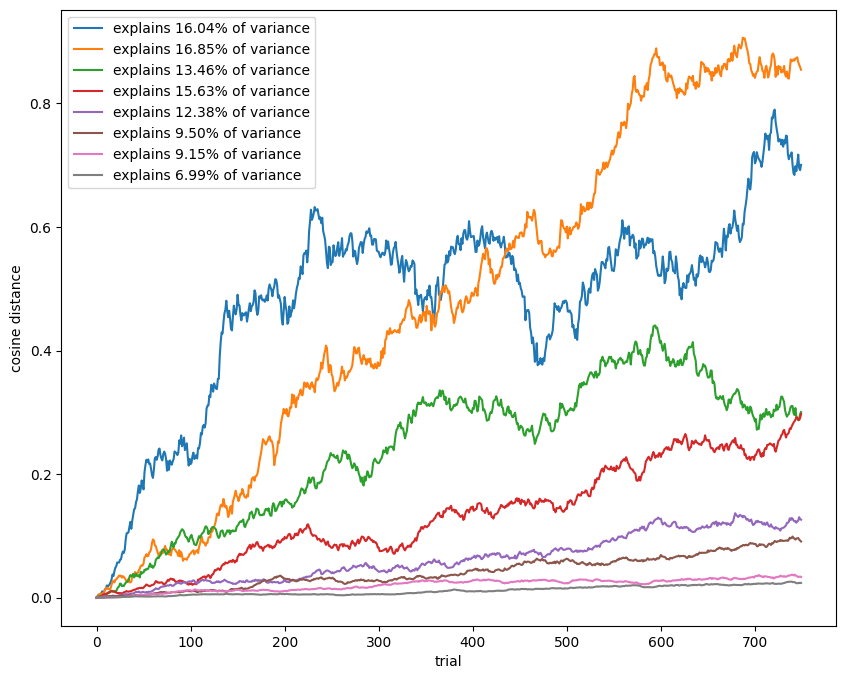

In [129]:
plt.figure(figsize=(10,8))
for d in range(D):
    plt.plot(true_cos_dists[d], label=f'explains {100*original_true_evs[d, 0]:.2f}% of variance')
plt.ylabel('cosine distance')
plt.xlabel('trial')
plt.legend()
plt.show()

In [130]:
rotated_true_cos_sims = np.zeros((D, num_trials))
rotated_true_cos_dists = np.zeros((D, num_trials))
for d in tqdm(range(D)):
    rotated_true_cos_sims[d] = vmap(compute_cos_sim, in_axes=(0, None))(rotated_true_emissions_weights[:,:,d], 
                                                                          rotated_true_emissions_weights[0,:,d])
    rotated_true_cos_dists[d] = vmap(compute_cos_dist, in_axes=(0, None))(rotated_true_emissions_weights[:,:,d], 
                                                                          rotated_true_emissions_weights[0,:,d])

100%|██████████| 8/8 [00:00<00:00, 255.09it/s]


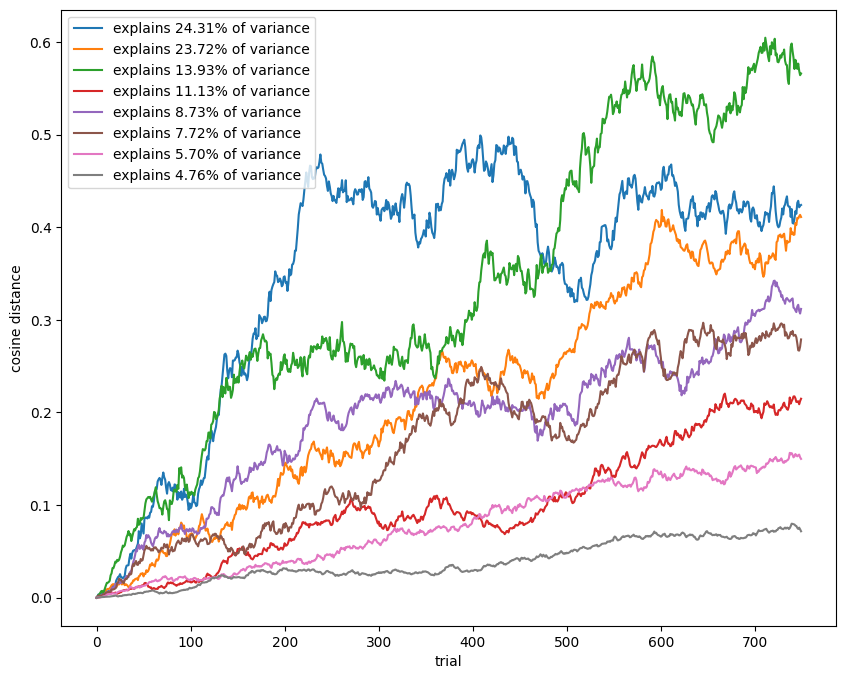

In [131]:
plt.figure(figsize=(10,8))
for d in range(D):
    plt.plot(rotated_true_cos_dists[d], label=f'explains {100*true_evs[d, 0]:.2f}% of variance')
plt.ylabel('cosine distance')
plt.xlabel('trial')
plt.legend()
plt.show()

In [132]:
rotated_true_cos_sims_diag = np.zeros((D, num_trials-1))
rotated_true_cos_dists_diag = np.zeros((D, num_trials-1))
for d in tqdm(range(D)):
    rotated_true_cos_sims_diag[d] = vmap(compute_cos_sim, in_axes=(0, 0))(rotated_true_emissions_weights[:-1,:,d], 
                                                                          rotated_true_emissions_weights[1:,:,d])
    rotated_true_cos_dists_diag[d] = vmap(compute_cos_dist, in_axes=(0, 0))(rotated_true_emissions_weights[:-1,:,d], 
                                                                            rotated_true_emissions_weights[1:,:,d])

100%|██████████| 8/8 [00:00<00:00, 220.67it/s]


In [133]:
true_diag_thetas = np.rad2deg(jnp.arccos(jnp.clip(rotated_true_cos_sims_diag, min=-1, max=1)))
true_diag_thetas = np.array(true_diag_thetas)

Ground-truth explained variance / mean axis drift correlation: 0.660
Explained variance order high-to-low: [0, 1, 2, 3, 4, 5, 6, 7]
Mean drift order high-to-low: [2, 0, 4, 1, 5, 3, 6, 7]


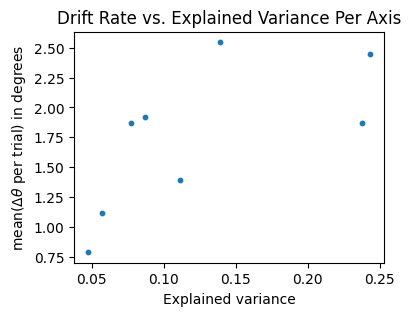

In [134]:
true_mean_axis_drift = true_diag_thetas.mean(1)
true_ev_drift_corr = np.corrcoef(np.asarray(true_evs).reshape(-1), np.asarray(true_mean_axis_drift).reshape(-1))[0, 1]
print(f"Ground-truth explained variance / mean axis drift correlation: {true_ev_drift_corr:.3f}")
print("Explained variance order high-to-low:", np.argsort(-np.asarray(true_evs).reshape(-1)).tolist())
print("Mean drift order high-to-low:", np.argsort(-np.asarray(true_mean_axis_drift).reshape(-1)).tolist())

plt.figure(figsize=(4,3))
plt.scatter(np.asarray(true_evs).reshape(-1), true_mean_axis_drift, s=10)
plt.title('Drift Rate vs. Explained Variance Per Axis')

plt.xlabel('Explained variance')
plt.ylabel('mean(' + r'$\Delta\theta$' + ' per trial) in degrees')
plt.show()

0 -1588905.5134920443 -11070.111042482631 -1577835.4024495617 0.0 1.0151029379371779e-07 6.595426366158614e-07 8.877971135837565e-06 0.17040801783576698
-----------------------------------------------------------------------------
1 -436865.10800162697 -10377.755570767287 -426487.3524308597 0.0 1.0375809781643113e-07 1.5161992566392058e-06 4.862625396269334e-06 0.12881597894774252
-----------------------------------------------------------------------------
2 -356095.7755501188 -10280.228420337497 -345815.54712978133 0.0 1.0625431865361607e-07 2.724533119193841e-06 3.246731384907311e-06 0.11875037755856252
-----------------------------------------------------------------------------
3 -321864.15825591085 -10196.647434011546 -311667.5108218993 0.0 1.0899026984940182e-07 4.159830289664708e-06 2.5467106722732277e-06 0.11526833573648608
-----------------------------------------------------------------------------
4 -306329.96850320796 -10132.247012800384 -296197.7214904076 0.0 1.1192236278

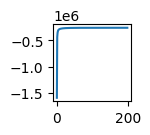

0.546287398901768


In [135]:
key = jr.PRNGKey(123)

ddof = D * (emission_dim - D) + D * (D - 1) // 2
test_model = StiefelManifoldSSM(D, 
                                N,
                                num_trials=len(emissions),
                                num_conditions=num_conditions,
                                has_dynamics_bias=False,
                                tau_per_dim=True,
                                fix_tau=False,
                                fix_initial_velocity=False,
                                fix_scale=True,
                                emissions_cov_eps=1e-9,
                                velocity_smoother_method='ekf',
                                ekf_mode='cov',
                                max_tau=1e-4,
                                ekf_num_iters=1,
                                initial_velocity_covariance_prior=IG(concentration=1e-6, scale=1e-6),
                                tau_prior=IG(concentration=1e-6, scale=1e-6),
                                )

base_subspace = PCA(n_components=N).fit(emissions.reshape(-1, N)).components_.T
emission_weights = jnp.tile(base_subspace[:, :D][None], (len(emissions), 1, 1))

# key, key_root = jr.split(key)
# random_rotation_matrix = random_dynamics_weights(key_root, D, 128) #jr.orthogonal(key_root, D)
# rotate_pca_components = PCA(n_components=N).fit(emissions.reshape(-1, N)).components_.T[:, :D] @ random_rotation_matrix
# key, key_root = jr.split(key)
# base_subspace = gram_schmidt(jnp.concatenate([rotate_pca_components, jr.normal(key_root, shape=(N, N-D))], axis=-1))
# emission_weights = jnp.tile(base_subspace[:, :D][None], (len(emissions), 1, 1))

key, key_root = jr.split(key)
test_params, param_props, _ = test_model.initialize(base_subspace=base_subspace,
                                                    tau=jnp.ones(ddof)*1e-7,
                                                    emission_weights=emission_weights,
                                                    initial_velocity_cov=1e-4*jnp.eye(ddof),
                                                    scale=jnp.ones((len(emissions), D)),
                                                    key=key)

test_params, marginal_lls = test_model.fit_em(test_params, param_props, 
                                              emissions,
                                              conditions=conditions,
                                              # trial_masks=trial_masks,
                                              # block_ids=block_ids,
                                              # block_masks=block_masks,
                                              num_iters=200,
                                              print_ll=True,
                                              run_velocity_smoother=False)

plt.figure(figsize=(1,1))
plt.plot(marginal_lls)
plt.show()

print(jnp.diff(jnp.array(marginal_lls)).min())

In [136]:
# inferred_emissions_weights = test_params.emissions.weights
num_blocks = num_trials
block_size = 1
sequence_length = num_timesteps
velocity_smoother = test_model.smoother(test_params, emissions.reshape(num_blocks, block_size, sequence_length, emission_dim), 
                                        conditions.reshape(num_blocks, block_size), jnp.ones(num_blocks, dtype=bool),
                                        method=1, num_iters=1)
Ev = velocity_smoother.smoothed_means

inferred_emissions_weights = vmap(rotate_subspace, in_axes=(None, None, 0))(test_params.emissions.base_subspace, D, Ev)


smds_rotation, explained_variances = compute_rotation(emissions, inferred_emissions_weights)
rotated_inferred_emissions_weights = jnp.einsum('rij,jk->rik', inferred_emissions_weights, smds_rotation)
inferred_evs = vmap(compute_explained_variance, in_axes=(None, None, -1))(emissions, rotated_inferred_emissions_weights, 
                                                                          rotated_inferred_emissions_weights[:, :, None])

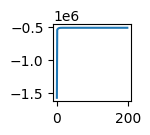

0.022149543976411223


In [137]:
key = jr.PRNGKey(123)

lds_D = D
lds_model = LinearGaussianConjugateSSM(lds_D, N, 
                                       num_conditions=num_conditions,
                                       has_dynamics_bias=True, has_emissions_bias=False)

base_subspace = PCA(n_components=N).fit(emissions.reshape(-1, N)).components_.T
emission_weights = base_subspace[:, :lds_D]

key, key_root = jr.split(key)
lds_params, param_props = lds_model.initialize(key=key, emission_weights=emission_weights)

lds_params, marginal_lls = lds_model.fit_em(lds_params, 
                                            param_props, 
                                            emissions,
                                            conditions=conditions,
                                            num_iters=200)
plt.figure(figsize=(1,1))
plt.plot(marginal_lls)
plt.show()

print(jnp.diff(jnp.array(marginal_lls)).min())

In [138]:
true_rotation, _ = compute_rotation(emissions, true_params.emissions.weights)
A = true_params.dynamics.weights
true_rotation_inv = jnp.linalg.inv(true_rotation)
transformed_true_A = true_rotation @ A @ true_rotation_inv

A = test_params.dynamics.weights
smds_rotation_inv = jnp.linalg.inv(smds_rotation)
transformed_smds_A = smds_rotation @ A @ smds_rotation_inv

lds_rotation, _ = compute_rotation(emissions, lds_params.emissions.weights)
A = lds_params.dynamics.weights
lds_rotation_inv = jnp.linalg.inv(lds_rotation)
transformed_lds_A = lds_rotation @ A @ lds_rotation_inv
# print(transformed_true_A.shape, transformed_smds_A.shape, transformed_lds_A.shape)

In [139]:
def plot_eigenvalues(
    true_A: np.ndarray,
    smds_A: np.ndarray,
    lds_A: np.ndarray,
    figsize: tuple = (4, 4),
    title: str = "eigenvalues of\nlatent dynamics",
):
    """
    Plot eigenvalues of two dynamics matrices in the complex plane.

    Parameters
    ----------
    A_stationary : np.ndarray
        Dynamics matrix expected to be (asymptotically) stable
        (eigenvalues inside or on the unit circle).
    A_nonstationary : np.ndarray
        Dynamics matrix that may be unstable or marginally stable.
    figsize : tuple, optional
        Size of the matplotlib figure.
    title : str, optional
        Title of the plot.
    """
    # --- compute eigenvalues -------------------------------------------------
    eig_true = np.linalg.eigvals(true_A)
    eig_smds = np.linalg.eigvals(smds_A)
    eig_lds = np.linalg.eigvals(lds_A)


    import matplotlib as mpl
    mpl.rcParams['pdf.fonttype'] = 42
    mpl.rcParams['ps.fonttype'] = 42
    # --- set up figure -------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("real Part", fontsize=12)
    ax.set_ylabel("imaginary Part", fontsize=12)
    ax.set_xticks([-1, -0.5, 0.0, 0.5, 1.0])
    ax.set_yticks([-1, -0.5, 0.0, 0.5, 1.0])
    ax.grid(True, linestyle="--", alpha=0.5)

    # Equal aspect so the unit circle looks like a circle
    ax.set_aspect("equal", adjustable="box")

    # --- unit circle ---------------------------------------------------------
    theta = np.linspace(0, 2 * np.pi, 400)
    ax.plot(np.cos(theta), np.sin(theta), "k--", lw=1.5)

    # --- scatter eigenvalues -------------------------------------------------
    ax.scatter(
        eig_true.real,
        eig_true.imag,
        c="k",
        marker="o",
        s=120,
        label="True SMDS",
    )
    ax.scatter(
        eig_smds.real,
        eig_smds.imag,
        color=np.array([180, 0, 0]) / 255,
        marker="o",
        s=60,
        label="Learned SMDS",
    )

    ax.scatter(
        eig_lds.real,
        eig_lds.imag,
        color=np.array([20, 0, 180]) / 255,
        marker="o",
        s=30,
        label="Learned LDS",
    )

    ax.legend(loc="lower left", fontsize=10)

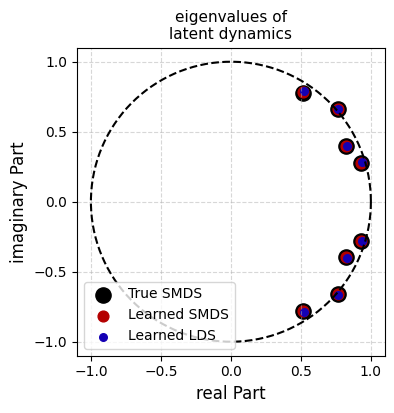

In [140]:
# plot_eigenvalues(transformed_true_A, transformed_smds_A, transformed_lds_A, figsize=(8,8))
# plot_eigenvalues(transformed_true_A, transformed_smds_A, transformed_smds_A, figsize=(8,8))
# plot_eigenvalues(transformed_true_A, transformed_lds_A, transformed_lds_A, figsize=(8,8))
plot_eigenvalues(transformed_true_A, transformed_smds_A, transformed_lds_A, figsize=(4,4))
plt.savefig('figure2_variance_drift/figure2b_dynamics_eigvals.pdf', 
            bbox_inches='tight', facecolor='white', transparent=True)
plt.show()

In [141]:
rotated_inferred_cos_sims = np.zeros((D, num_trials, num_trials))
rotated_inferred_cos_dists = np.zeros((D, num_trials, num_trials))
for d in tqdm(range(D)):
    for b in range(num_trials):
        rotated_inferred_cos_sims[d, b] = vmap(compute_cos_sim, in_axes=(None, 0))(rotated_inferred_emissions_weights[b,:,d], 
                                                                              rotated_inferred_emissions_weights[:,:,d])
        rotated_inferred_cos_dists[d, b] = vmap(compute_cos_dist, in_axes=(None, 0))(rotated_inferred_emissions_weights[b,:,d], 
                                                                              rotated_inferred_emissions_weights[:,:,d])

inferred_thetas = np.rad2deg(jnp.arccos(jnp.clip(rotated_inferred_cos_sims, min=-1, max=1)))
inferred_thetas = np.array(inferred_thetas)

max_drift_amounts = []
for i in range(D):
    max_drift_amounts.append(inferred_thetas[i][jnp.triu_indices(inferred_thetas.shape[-1], k=1)].max())

rotated_true_cos_sims = np.zeros((D, num_trials, num_trials))
rotated_true_cos_dists = np.zeros((D, num_trials, num_trials))
for d in tqdm(range(D)):
    for b in range(num_trials):
        rotated_true_cos_sims[d, b] = vmap(compute_cos_sim, in_axes=(None, 0))(rotated_true_emissions_weights[b,:,d], 
                                                                              rotated_true_emissions_weights[:,:,d])
        rotated_true_cos_dists[d, b] = vmap(compute_cos_dist, in_axes=(None, 0))(rotated_true_emissions_weights[b,:,d], 
                                                                              rotated_true_emissions_weights[:,:,d])

true_thetas = np.rad2deg(jnp.arccos(jnp.clip(rotated_true_cos_sims, min=-1, max=1)))
true_thetas = np.array(true_thetas)

true_max_drift_amounts = []
for i in range(D):
    true_max_drift_amounts.append(true_thetas[i][jnp.triu_indices(true_thetas.shape[-1], k=1)].max())

100%|██████████| 8/8 [00:22<00:00,  2.85s/it]


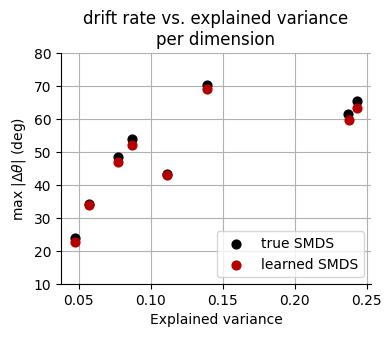

In [148]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
# mpl.rcParams['font.sans-serif'] = 'Arial'
mpl.rcParams['ps.fonttype'] = 42

fig, ax = plt.subplots(figsize=(4,3))
plt.grid(True, zorder=0)
ax.scatter(true_evs, true_max_drift_amounts, s=40, color='k', label='true SMDS', zorder=3)
ax.scatter(inferred_evs, max_drift_amounts, s=40, color=np.array([180, 0, 0]) / 255, label='learned SMDS', zorder=3)
# ax.set_title('Drift Rate vs. Explained Variance Per Axis')

ax.set_xlabel('Explained variance')
# ax.set_ylabel('mean(' + r'$|\Delta\theta|$' + ' per trial) in degrees')
ax.set_ylabel('max ' + r'$|\Delta\theta|$' + ' (deg)')
ax.legend()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.ylim(10, 80)
# plt.xlim(0, 0.2)
plt.title('drift rate vs. explained variance\nper dimension')

plt.savefig('figure2_variance_drift/figure2b_max_drift.pdf', bbox_inches='tight', 
            facecolor='white', transparent=True)
plt.show()

In [143]:
subspace_angle_matrix = compute_subspace_angle_matrix_v2(rotated_inferred_emissions_weights[:, :, :])
inferred_normalized_grassmann_dist_matrix = jnp.linalg.norm(subspace_angle_matrix, ord=2, axis=-1) / (jnp.sqrt(state_dim) * jnp.pi / 2)

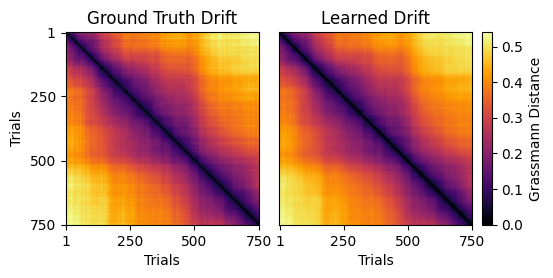

In [144]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

fig, axs = plt.subplots(1, 2, figsize=(5.5,2.5), gridspec_kw={'width_ratios': [1, 1.1], 'wspace': 0.1})

vmin = jnp.concatenate([normalized_grassmann_dist_matrix, inferred_normalized_grassmann_dist_matrix]).min()
vmax = jnp.concatenate([normalized_grassmann_dist_matrix, inferred_normalized_grassmann_dist_matrix]).max()

axs[0].imshow(normalized_grassmann_dist_matrix, aspect='auto', interpolation='none', vmin=vmin, vmax=vmax, cmap='inferno')
axs[0].set_ylabel('Trials')
axs[0].set_xlabel('Trials')
axs[0].set_yticks([1, 250, 500, 750])
axs[0].set_xticks([1, 250, 500, 750])
axs[0].set_title('Ground Truth Drift')

im = axs[1].imshow(inferred_normalized_grassmann_dist_matrix, aspect='auto', interpolation='none', vmin=vmin, vmax=vmax, cmap='inferno')
axs[1].set_yticks([])
axs[1].set_xticks([1, 250, 500, 750])
axs[1].set_xlabel('Trials')
axs[1].set_title('Learned Drift')
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(im, cax=cax)
cbar.ax.set_ylabel(r'Grassmann Distance')

plt.savefig('figure2_variance_drift/figure2b_off_manifold_drift.pdf', bbox_inches='tight', facecolor='white', transparent=True)
plt.show()

In [145]:
# twist_angle_matrix = compute_twist_angle_matrix(true_emissions_weights[:, :, :])
twist_angle_matrix = compute_twist_angle_matrix(torch.tensor(np.array(rotated_inferred_emissions_weights, copy=True), device='cuda'))
twist_angle_matrix = jnp.array(twist_angle_matrix.cpu().numpy())
d_in_max = jnp.pi * jnp.sqrt(D // 2)
inferred_normalized_twist_angle_matrix = jnp.clip(twist_angle_matrix / d_in_max, 0.0, 1.0)

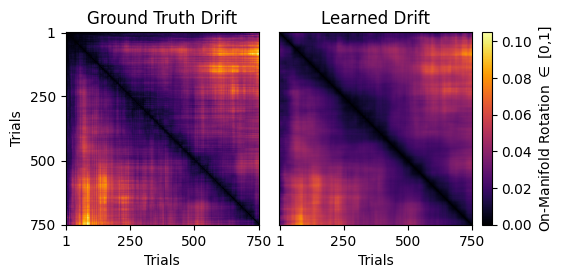

In [146]:
fig, axs = plt.subplots(1, 2, figsize=(5.5,2.5), gridspec_kw={'width_ratios': [1, 1.1], 'wspace': 0.1})

vmin = jnp.concatenate([normalized_twist_angle_matrix, inferred_normalized_twist_angle_matrix]).min()
vmax = jnp.concatenate([normalized_twist_angle_matrix, inferred_normalized_twist_angle_matrix]).max()

axs[0].imshow(normalized_twist_angle_matrix, aspect='auto', interpolation='none', vmin=vmin, vmax=vmax, cmap='inferno')
axs[0].set_ylabel('Trials')
axs[0].set_xlabel('Trials')
axs[0].set_yticks([1, 250, 500, 750])
axs[0].set_xticks([1, 250, 500, 750])
axs[0].set_title('Ground Truth Drift')

im = axs[1].imshow(inferred_normalized_twist_angle_matrix, aspect='auto', interpolation='none', vmin=vmin, vmax=vmax, cmap='inferno')
axs[1].set_yticks([])
axs[1].set_xticks([1, 250, 500, 750])
axs[1].set_xlabel('Trials')
axs[1].set_title('Learned Drift')
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(im, cax=cax)
cbar.ax.set_ylabel(r'On-Manifold Rotation $\in$ [0,1]')

plt.savefig('figure2_variance_drift/figure2b_on_manifold_drift.pdf', bbox_inches='tight', facecolor='white', transparent=True)
plt.show()

In [ ]:
block_size = 1
num_blocks = len(emissions) // block_size
print(num_blocks)
num_trials = num_blocks * block_size
emissions = emissions[:num_trials]
conditions = conditions[:num_trials]

block_masks = jnp.ones(num_blocks, dtype=bool)
trial_masks = jnp.ones(len(emissions), dtype=bool)
num_test_blocks = num_blocks // 6
key = jr.PRNGKey(2626)
# key = jr.PRNGKey(66123)

test_idx = jax.random.choice(key, jnp.arange(30, num_blocks-30, dtype=int), shape=(num_test_blocks,), replace=False)

block_masks = block_masks.at[test_idx].set(False)
num_train_blocks = block_masks.sum()
print(num_train_blocks)
block_ids = jnp.repeat(jnp.eye(num_blocks), block_size, axis=1)

trial_masks = jnp.repeat(block_masks, block_size)

train_obs = emissions
_, sequence_length, emission_dim = train_obs.shape
test_obs = train_obs[~trial_masks]

train_conditions = conditions[trial_masks]
test_conditions = conditions[~trial_masks]

print(len(jnp.unique(train_conditions)))

In [ ]:
plt.figure(figsize=(24,2))
for i in np.where(~trial_masks)[0]:
    plt.axvspan(i, i+1, alpha=0.5, color='r')
plt.xlim(0, len(emissions))
# plt.ylabel('Geodesic distance')
plt.xlabel('Trials')
plt.show()

In [ ]:
xy_ekf_marginal_ll = true_model.marginal_log_prob(true_params, train_obs.reshape(num_blocks, block_size, sequence_length, emission_dim), 
                                                  conditions=conditions.reshape(num_blocks, block_size), block_masks=jnp.ones(num_blocks, dtype=bool),
                                                  trial_masks=jnp.ones((num_blocks, block_size), dtype=bool),
                                                  method=1, num_iters=1)
y_ekf_marginal_ll = true_model.marginal_log_prob(true_params, train_obs.reshape(num_blocks, block_size, sequence_length, emission_dim), 
                                                 conditions=conditions.reshape(num_blocks, block_size), block_masks=block_masks, 
                                                 trial_masks=trial_masks.reshape(num_blocks, block_size),
                                                 method=1, num_iters=1)
true_ekf_marginal_ll = xy_ekf_marginal_ll - y_ekf_marginal_ll
print(true_ekf_marginal_ll)

In [ ]:
stationary_test_state_dims = np.arange(4, 18, 2)
num_iters = 200
key = jr.PRNGKey(123456)
test_marginal_lls = []
for test_state_dim in stationary_test_state_dims:
    test_model = LinearGaussianConjugateSSM(test_state_dim, emission_dim, 
                                            num_conditions=num_conditions,
                                            has_dynamics_bias=False, has_emissions_bias=False)
            
    key, this_key = jr.split(key, 2)

    base_subspace = PCA(n_components=emission_dim).fit(train_obs[trial_masks].reshape(-1, emission_dim)).components_.T
    emission_weights = base_subspace[:, :test_state_dim]
    
    test_params, param_props = test_model.initialize(key=this_key, 
                                                     emission_weights=emission_weights
                                                    )
    
    test_params, marginal_lls = test_model.fit_em(test_params, 
                                                  param_props, 
                                                  train_obs[trial_masks],
                                                  conditions=train_conditions,
                                                  num_iters=num_iters)
    
    plt.figure(figsize=(1,1))
    plt.plot(marginal_lls)
    plt.show()

    plt.figure(figsize=(1,1))
    plt.plot(marginal_lls[1:])
    plt.show()

    plt.figure(figsize=(1,1))
    plt.plot(marginal_lls[100:])
    plt.show()

    print(test_state_dim, marginal_lls[-1])
    print(monotonically_increasing(jnp.array(marginal_lls), rtol=1e-2, atol=1e-2))
    print(jnp.diff(jnp.array(marginal_lls)).min())

    test_marginal_ll = test_model.batch_marginal_log_prob(test_params, test_obs, conditions=test_conditions)

    print(jnp.diag(test_params.emissions.cov).min())
    
    test_marginal_lls.append(test_marginal_ll)
    print(test_state_dim, test_marginal_ll)

In [ ]:
plt.axhline(true_ekf_marginal_ll)
plt.plot(stationary_test_state_dims, test_marginal_lls)

In [ ]:
# run this
key = jr.PRNGKey(123456)
test_state_dims = [4, 6, 8, 10, 12, 14, 16]
test_ekf_marginal_lls = []
num_iters = 200
for test_state_dim in test_state_dims:
    ddof = test_state_dim * (emission_dim - test_state_dim) + test_state_dim * (test_state_dim - 1) // 2
    # dof = (test_state_dim, emission_dim - test_state_dim)
    test_model = StiefelManifoldSSM(test_state_dim, 
                                    emission_dim,
                                    num_trials=len(train_obs),
                                    num_conditions=num_conditions,
                                    has_dynamics_bias=False,
                                    tau_per_dim=True,
                                    tau_per_axis=False,
                                    fix_tau=False,
                                    fix_initial_velocity=False,
                                    fix_scale=True,
                                    emissions_cov_eps=1e-5,
                                    velocity_smoother_method='ekf',
                                    ekf_mode='cov',
                                    max_tau=1e-3,
                                    ekf_num_iters=1,
                                    initial_velocity_covariance_prior=IG(concentration=1e-6, scale=1e-6),
                                    tau_prior=IG(concentration=1e-6, scale=1e-6),
                                    )

    base_subspace = PCA(n_components=emission_dim).fit(train_obs[trial_masks].reshape(-1, emission_dim)).components_.T
    emission_weights = jnp.tile(base_subspace[:, :test_state_dim][None], (len(train_obs), 1, 1))
    
    key, key_root = jr.split(key)
    test_params, param_props, _ = test_model.initialize(base_subspace=base_subspace,
                                                tau=jnp.ones(ddof)*1e-6,
                                                emission_weights=emission_weights,
                                                initial_velocity_cov=1e-4*jnp.eye(ddof),
                                                scale=jnp.ones((len(train_obs), test_state_dim)),
                                                key=key)
    
    test_params, marginal_lls = test_model.fit_em(test_params, param_props, 
                                                  train_obs,
                                                  conditions=conditions,
                                                  trial_masks=trial_masks,
                                                  block_ids=block_ids,
                                                  block_masks=block_masks,
                                                  num_iters=num_iters,
                                                  print_ll=True,
                                                  run_velocity_smoother=False)

    plt.figure(figsize=(1,1))
    plt.plot(marginal_lls)
    plt.show()
    
    print(jnp.diff(jnp.array(marginal_lls)).min(), jnp.argmax(marginal_lls))

    start_time = time.time()
    xy_ekf_marginal_ll = test_model.marginal_log_prob(test_params, train_obs.reshape(num_blocks, block_size, sequence_length, emission_dim), 
                                                      conditions=conditions.reshape(num_blocks, block_size), block_masks=jnp.ones(num_blocks, dtype=bool),
                                                      trial_masks=jnp.ones((num_blocks, block_size), dtype=bool),
                                                      method=1, num_iters=1)
    y_ekf_marginal_ll = test_model.marginal_log_prob(test_params, train_obs.reshape(num_blocks, block_size, sequence_length, emission_dim), 
                                                     conditions=conditions.reshape(num_blocks, block_size), block_masks=block_masks, 
                                                     trial_masks=trial_masks.reshape(num_blocks, block_size),
                                                     method=1, num_iters=1)
    test_ekf_marginal_ll = xy_ekf_marginal_ll - y_ekf_marginal_ll

    end_time = time.time()  # Record the end time
    
    elapsed_time = end_time - start_time  # Calculate the elapsed time in seconds
    print(f"Elapsed time: {elapsed_time:.6f} seconds")  # Print with microsecond precision    
    test_ekf_marginal_lls.append(test_ekf_marginal_ll)

    print(test_state_dim, test_ekf_marginal_ll)

In [ ]:
test_marginal_lls = np.array(test_marginal_lls)
test_ekf_marginal_lls = np.array(test_ekf_marginal_lls)

In [ ]:
num_test_samples = (num_trials // 6) * N * num_timesteps

In [ ]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

fig, ax = plt.subplots(figsize=(3,2.5))
plt.grid(True, zorder=0)

ax.axhline(true_ekf_marginal_ll / num_test_samples, color='k', linestyle=':', label='True SMDS', zorder=0, linewidth=2)

ax.plot(test_state_dims, test_ekf_marginal_lls / num_test_samples, marker='o', color='r', label='SMDS', zorder=3, linewidth=2)

ax.plot(stationary_test_state_dims, test_marginal_lls / num_test_samples, marker='o', color='b', label='LDS', zorder=3, linewidth=2)


ax.axvline(8, color='k', linestyle='-', zorder=2, linewidth=2)
ax.text(8.2, -0.75, 'True Dim.', rotation=90, fontsize=10)
# ax.legend(loc='lower left')
ax.set_xlabel('Latent State Dim.')
ax.set_ylabel('Normalized\nTest Log-likelihood')
ax.set_xticks(stationary_test_state_dims)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.05), fontsize=10)

plt.savefig('figure2_variance_drift/figure2b_test_ll.pdf', 
            bbox_inches='tight', facecolor='white', transparent=True)

plt.show()